In [ ]:
#### new

import pandas as pd

# Load datasets
soil_df = pd.read_csv("soil_profile_dataset.csv")            # your real file
project_df = pd.read_csv("project_dataset.csv")              # your real file

# Pivot project dataset to get one row per WISE_ID with one-hot encoded columns
suitability_df = project_df.pivot_table(
  index="WISE_ID",
    columns="ConstructionType",
    values="Success",
    aggfunc="first"  # Assumes one entry per type per ID
  ).fillna(False).astype(bool).astype(int).reset_index()

# Merge soil profile with one-hot encoded suitability
combined_df = pd.merge(soil_df, suitability_df, on="WISE_ID", how="left")

# Save or view
combined_df.to_csv("combined_labeled_dataset.csv", index=False)
print(combined_df.head())


import pandas as pd

# Load the real CSV files
soil_df = pd.read_csv("soil_profile_dataset.csv")
project_df = pd.read_csv("project_dataset.csv")

# Clean column names just in case
project_df.columns = project_df.columns.str.strip()

# Pivot the project dataset to get one-hot encoded Success for each construction type
suit_df = project_df.pivot_table(
    index="WISE_ID",
    columns="ConstructionType",
    values="Success",
    aggfunc="first"  # Assumes one entry per type per ID
).fillna(False).astype(bool).astype(int).reset_index()

# Merge suitability info into every soil layer by WISE_ID
combined_df = soil_df.merge(suit_df, on="WISE_ID", how="left")

# Save the combined dataset
combined_df.to_csv("final_combined_by_layer.csv", index=False)

# Preview the result
print(combined_df.head())



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
from google.colab import files
import io

# ===================== Upload & Merge =====================
pd_uploaded = files.upload()
sd_uploaded = files.upload()

project_file_name = list(pd_uploaded.keys())[0]
soil_file_name = list(sd_uploaded.keys())[0]

project_df = pd.read_csv(io.BytesIO(pd_uploaded[project_file_name]))
soil_df = pd.read_csv(io.BytesIO(sd_uploaded[soil_file_name]))

soil_agg = soil_df.groupby("WISE_ID").mean().reset_index()
merged_df = pd.merge(project_df, soil_agg, on="WISE_ID")

merged_df.to_csv("merged_dataset.csv", index=False)
files.download("merged_dataset.csv")

# ===================== Features & Target =====================
X = merged_df.drop(columns=[
    "WISE_ID", "Success", "LoadBearingCapacity (kPa)",
    "AlternativeUse", "ModificationRecommendation"
])
y = merged_df["Success"].astype(int)

categorical_cols = ["ConstructionType"]
numerical_cols = X.columns.difference(categorical_cols)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# ===================== Train-Test Split =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# ===================== Fit & Evaluate =====================
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nClassification Report:\n", classification_report(y_test, y_pred))
plt.rcParams.update({'font.size': 14})
# ===================== Figures (Save at 300 dpi) =====================
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
ax[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
ax[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
ax[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig("model_evaluation_figures.png", dpi=300, bbox_inches="tight")
files.download("model_evaluation_figures.png")
plt.close()

# ===================== K-Fold Cross Validation =====================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
print("\nCross-Validation Results:")
print("Accuracy per fold:", cv_scores)
print("Mean CV Accuracy: {:.4f} ± {:.4f}".format(cv_scores.mean(), cv_scores.std()))


Saving project_dataset.csv to project_dataset (3).csv


Saving soil_profile_dataset.csv to soil_profile_dataset (3).csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.84      0.90      2223
           1       0.56      0.89      0.69       508

    accuracy                           0.85      2731
   macro avg       0.77      0.87      0.80      2731
weighted avg       0.90      0.85      0.86      2731



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Cross-Validation Results:
Accuracy per fold: [0.86086957 0.85858124 0.83935927 0.86034799 0.85393773]
Mean CV Accuracy: 0.8546 ± 0.0080


Actual code _ LR


Saving project_dataset.csv to project_dataset (10).csv


Saving soil_profile_dataset.csv to soil_profile_dataset (10).csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94      2223
           1       0.75      0.65      0.69       508

    accuracy                           0.89      2731
   macro avg       0.83      0.80      0.82      2731
weighted avg       0.89      0.89      0.89      2731


Cross-validation Accuracy Scores: [0.89993899 0.89444783 0.90659341 0.9029304  0.88644689]
Mean CV Accuracy: 0.8980715034406309


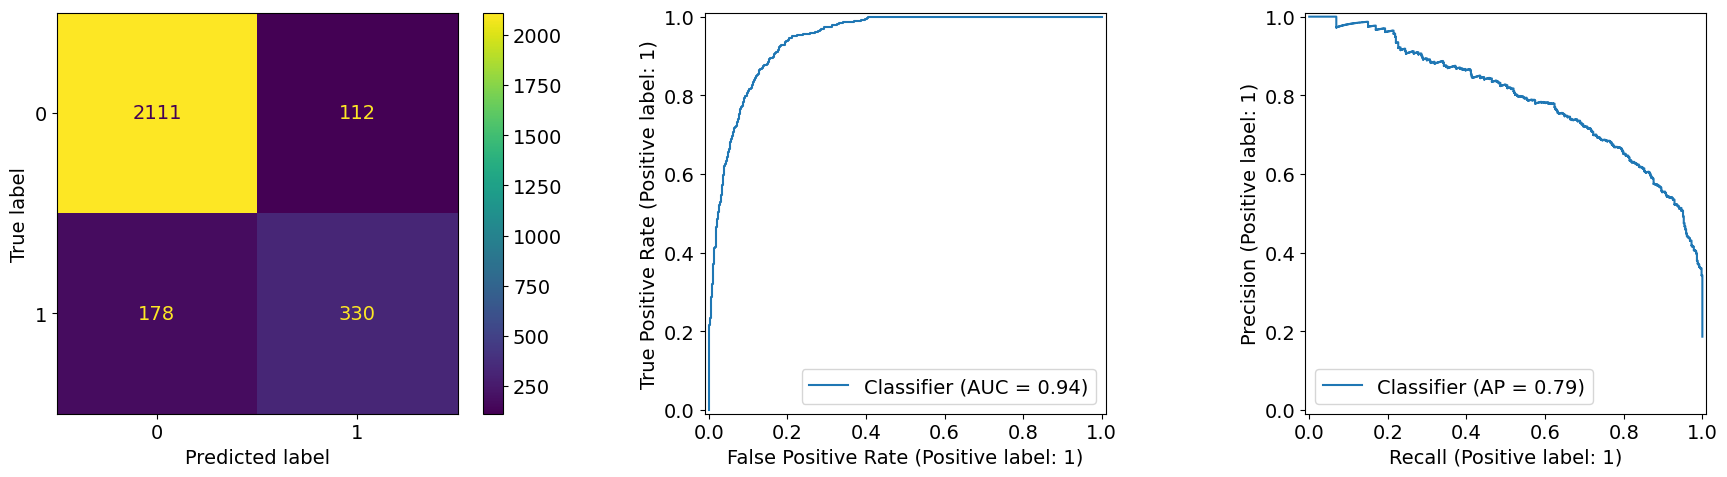

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MAE: 0.1486
RMSE: 0.2710
R²: 0.5150


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
from google.colab import files
import io

# Upload files
pd_uploaded = files.upload()
sd_uploaded = files.upload()

project_file_name = list(pd_uploaded.keys())[0]
soil_file_name = list(sd_uploaded.keys())[0]

# Read CSVs
project_df = pd.read_csv(io.BytesIO(pd_uploaded[project_file_name]))
soil_df = pd.read_csv(io.BytesIO(sd_uploaded[soil_file_name]))

# Merge datasets
soil_agg = soil_df.groupby("WISE_ID").mean().reset_index()
merged_df = pd.merge(project_df, soil_agg, on="WISE_ID")

# Save merged dataset
merged_df.to_csv("merged_dataset.csv", index=False)
files.download("merged_dataset.csv")  # For Google Colab download

# Features & Target
X = merged_df.drop(columns=[
    "WISE_ID", "Success", "LoadBearingCapacity (kPa)", "AlternativeUse", "ModificationRecommendation"
])
y = merged_df["Success"].astype(int)

categorical_cols = ["ConstructionType"]
numerical_cols = X.columns.difference(categorical_cols)

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# Fit model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))

# K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
print("\nCross-validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Plots
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
#ax[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
#ax[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
#ax[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig("evaluation_LR.png", dpi=300, bbox_inches="tight")  # Save at 300 dpi
plt.show()

# Download high-res plot
files.download("evaluation_LR.png")
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# ---- Regression-like metrics using probabilities ----
mae = mean_absolute_error(y_test, y_prob)
rmse = np.sqrt(mean_squared_error(y_test, y_prob))
r2 = r2_score(y_test, y_prob)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Random Forest

Saving project_dataset.csv to project_dataset (11).csv


Saving soil_profile_dataset.csv to soil_profile_dataset (11).csv

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      2223
           1       0.83      0.76      0.79       508

    accuracy                           0.93      2731
   macro avg       0.89      0.86      0.87      2731
weighted avg       0.92      0.93      0.93      2731



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

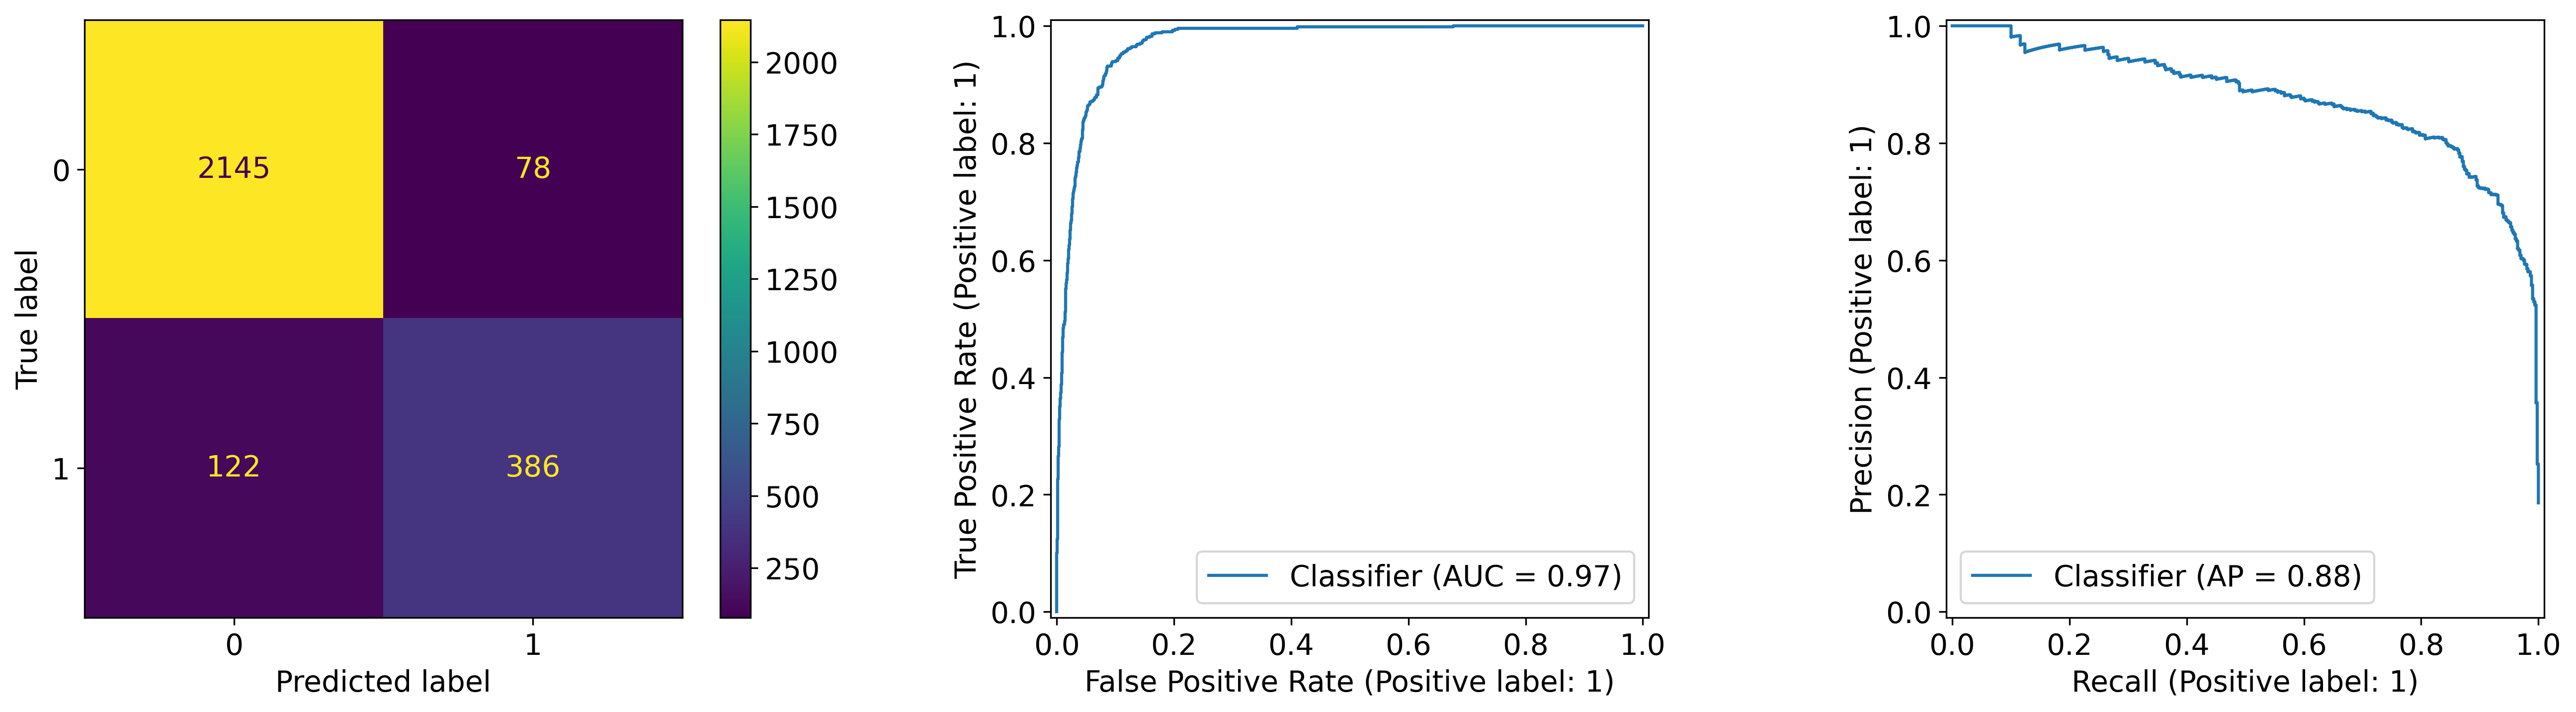

MAE: 0.1451
RMSE: 0.2365
R²: 0.6307


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
from google.colab import files
import io

# ---- Upload files ----
pd_uploaded = files.upload()
sd_uploaded = files.upload()

project_file_name = list(pd_uploaded.keys())[0]
soil_file_name = list(sd_uploaded.keys())[0]

# ---- Read datasets ----
project_df = pd.read_csv(io.BytesIO(pd_uploaded[project_file_name]))
soil_df = pd.read_csv(io.BytesIO(sd_uploaded[soil_file_name]))

# ---- Aggregate soil data and merge ----
soil_agg = soil_df.groupby("WISE_ID").mean().reset_index()
merged_df = pd.merge(project_df, soil_agg, on="WISE_ID")

# ---- Features & Target ----
X = merged_df.drop(columns=[
    "WISE_ID", "Success", "LoadBearingCapacity (kPa)",
    "AlternativeUse", "ModificationRecommendation"
])
y = merged_df["Success"].astype(int)

categorical_cols = ["ConstructionType"]
numerical_cols = X.columns.difference(categorical_cols)

# ---- Preprocessor ----
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# ---- Random Forest with Given Parameters ----
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=379,
        max_depth=50,
        min_samples_split=7,
        min_samples_leaf=1,
        max_features="log2",
        class_weight="balanced",
        random_state=42
    ))
])

# ---- Train-Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# ---- Train Model ----
final_model.fit(X_train, y_train)

# ---- Predictions ----
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# ---- Classification Report ----
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred))

# ---- Evaluation Plots ----
# Plots
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
#ax[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
#ax[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
#ax[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig("rf_evaluation.png", dpi=300, bbox_inches="tight")
files.download("rf_evaluation.png")
plt.show()

# ---- Regression-like metrics using probabilities ----
mae = mean_absolute_error(y_test, y_prob)
rmse = np.sqrt(mean_squared_error(y_test, y_prob))
r2 = r2_score(y_test, y_prob)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


Saving project_dataset.csv to project_dataset (8).csv


Saving soil_profile_dataset.csv to soil_profile_dataset (8).csv
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV Score: 0.9250487022299104
Best Parameters: {'classifier__max_depth': np.int64(50), 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 7, 'classifier__n_estimators': 379}

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      2223
           1       0.83      0.76      0.79       508

    accuracy                           0.93      2731
   macro avg       0.89      0.86      0.87      2731
weighted avg       0.92      0.93      0.93      2731



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

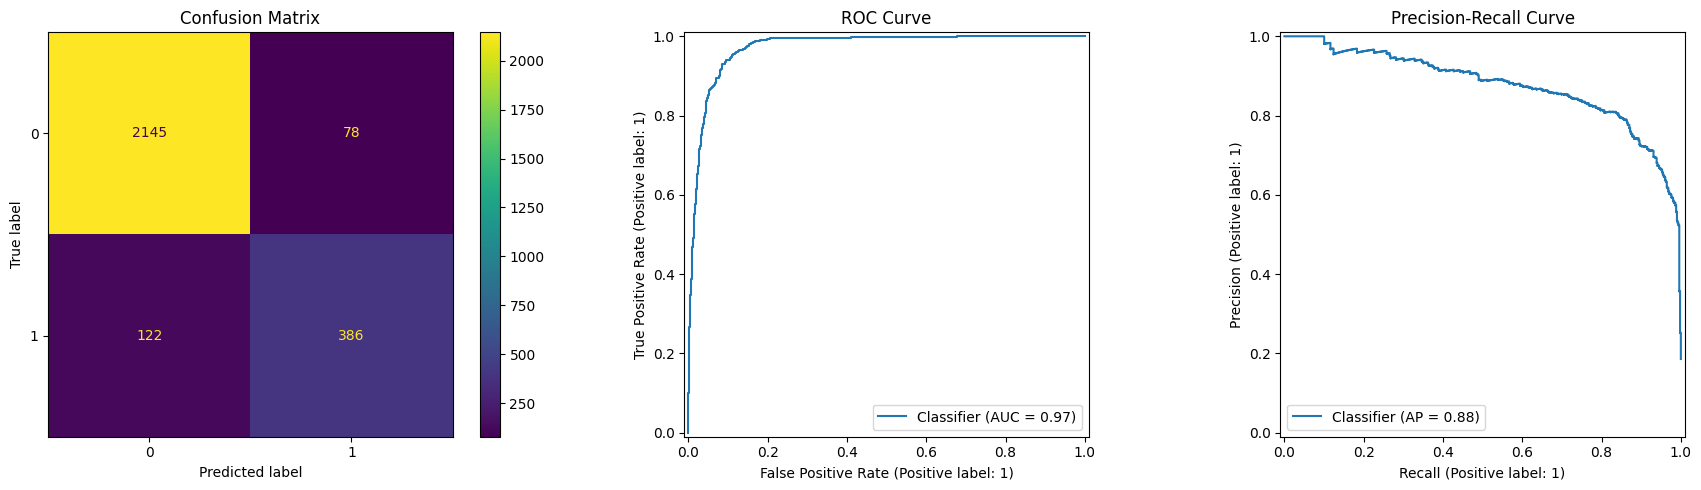

MAE: 0.1451
RMSE: 0.2365
R²: 0.6307


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
from scipy.stats import randint
from google.colab import files
import io

# ---- Upload files ----
pd_uploaded = files.upload()
sd_uploaded = files.upload()

project_file_name = list(pd_uploaded.keys())[0]
soil_file_name = list(sd_uploaded.keys())[0]

# ---- Read datasets ----
project_df = pd.read_csv(io.BytesIO(pd_uploaded[project_file_name]))
soil_df = pd.read_csv(io.BytesIO(sd_uploaded[soil_file_name]))

# ---- Aggregate soil data and merge ----
soil_agg = soil_df.groupby("WISE_ID").mean().reset_index()
merged_df = pd.merge(project_df, soil_agg, on="WISE_ID")

# ---- Features & Target ----
X = merged_df.drop(columns=[
    "WISE_ID", "Success", "LoadBearingCapacity (kPa)", "AlternativeUse", "ModificationRecommendation"
])
y = merged_df["Success"].astype(int)

categorical_cols = ["ConstructionType"]
numerical_cols = X.columns.difference(categorical_cols)

# ---- Preprocessor ----
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# ---- Pipeline with Random Forest ----
base_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))
])

# ---- Train-Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# ---- Randomized Search + Cross-validation ----
param_dist = {
    "classifier__n_estimators": randint(100, 1000),
    "classifier__max_depth": [None] + list(np.arange(5, 51, 5)),
    "classifier__min_samples_split": randint(2, 20),
    "classifier__min_samples_leaf": randint(1, 10),
    "classifier__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=50,                # number of random parameter settings to try
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best CV Score:", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)

# ---- Final Model ----
best_model = random_search.best_estimator_

# ---- Evaluate on Test Set ----
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred))

# ---- Plots ----
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
ax[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
ax[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
ax[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=300)
files.download("evaluation_plots.png")
plt.show()
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# ---- Regression-like metrics using probabilities ----
mae = mean_absolute_error(y_test, y_prob)
rmse = np.sqrt(mean_squared_error(y_test, y_prob))
r2 = r2_score(y_test, y_prob)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")



XGBOOST

Saving project_dataset.csv to project_dataset (12).csv


Saving soil_profile_dataset.csv to soil_profile_dataset (12).csv


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:33:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2223
           1       0.87      0.82      0.85       508

    accuracy                           0.94      2731
   macro avg       0.91      0.90      0.91      2731
weighted avg       0.94      0.94      0.94      2731



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:33:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:33:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:33:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:33:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:33:48] WARNING: /w

Cross-validation scores: [0.8993135  0.92036613 0.90251716 0.89514652 0.89697802]
Mean CV Accuracy: 0.9028642676926429


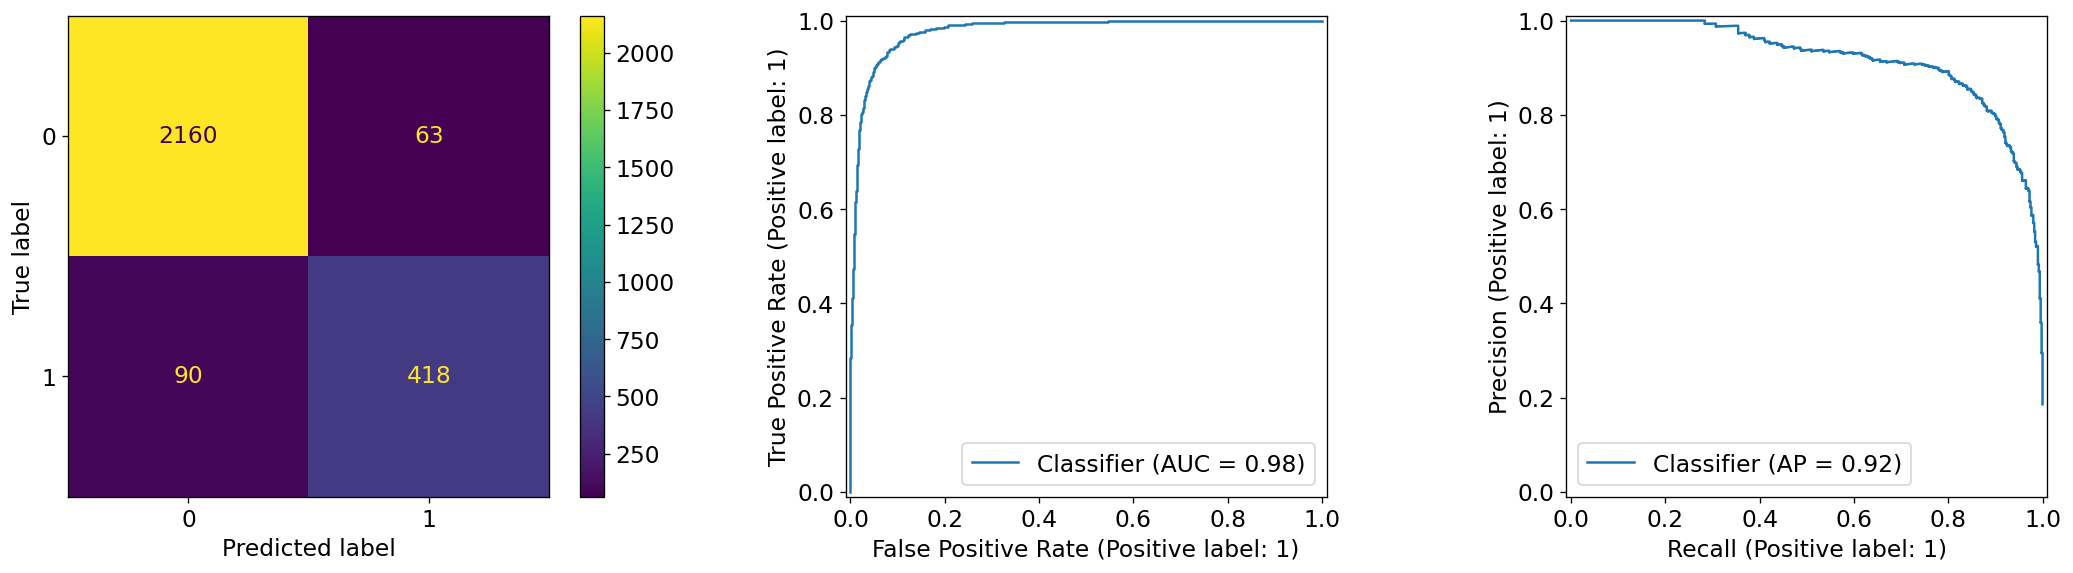

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MAE: 0.0801
RMSE: 0.2062
R²: 0.7193


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from google.colab import files
import io
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Upload files
pd_uploaded = files.upload()
sd_uploaded = files.upload()
project_file_name = list(pd_uploaded.keys())[0]
soil_file_name = list(sd_uploaded.keys())[0]

# Load data
project_df = pd.read_csv(io.BytesIO(pd_uploaded[project_file_name]))
soil_df = pd.read_csv(io.BytesIO(sd_uploaded[soil_file_name]))

# Aggregate soil data by WISE_ID
soil_agg = soil_df.groupby("WISE_ID").mean().reset_index()
merged_df = pd.merge(project_df, soil_agg, on="WISE_ID")

# Define features and target
X = merged_df.drop(columns=[
    "WISE_ID", "Success", "LoadBearingCapacity (kPa)",
    "AlternativeUse", "ModificationRecommendation"
])
y = merged_df["Success"].astype(int)

# Categorical & numerical columns
categorical_cols = ["ConstructionType"]
numerical_cols = X.columns.difference(categorical_cols)

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# Model pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(use_label_encoder=False, eval_metric="logloss",
                                 scale_pos_weight=1, random_state=42))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation report
print(classification_report(y_test, y_pred))

# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Plot results
# Plots
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
#ax[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
#ax[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
#ax[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

# Save plots for download
fig.savefig("model_evaluation_XGB.png", dpi=300, bbox_inches="tight")
files.download("model_evaluation_XGB.png")


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# ---- Regression-like metrics using probabilities ----
mae = mean_absolute_error(y_test, y_prob)
rmse = np.sqrt(mean_squared_error(y_test, y_prob))
r2 = r2_score(y_test, y_prob)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

SVM


Saving project_dataset.csv to project_dataset (13).csv


Saving soil_profile_dataset.csv to soil_profile_dataset (13).csv
Project Data:
  WISE_ID      ConstructionType  LoadBearingCapacity (kPa)  \
0   AR041  Residential Building                         50   
1   AR041    High-rise Building                        150   
2   AR041              Low-rise                        100   
3   AR041      Roads & Highways                         70   
4   AR041               Bridges                        120   

         AlternativeUse          ModificationRecommendation  Success  
0                   NaN                                 NaN     True  
1  Residential Building  Reduce liquid limit via compaction    False  
2  Residential Building  Reduce liquid limit via compaction    False  
3                   NaN                                 NaN     True  
4  Residential Building  Reduce liquid limit via compaction    False  

Soil Data:
  WISE_ID  TOPDEP  BOTDEP  SAND  SILT  CLAY  GRAVEL  BULKDENS   OMC  MDD  \
0   AR041     0.0    26.0  47.0  3

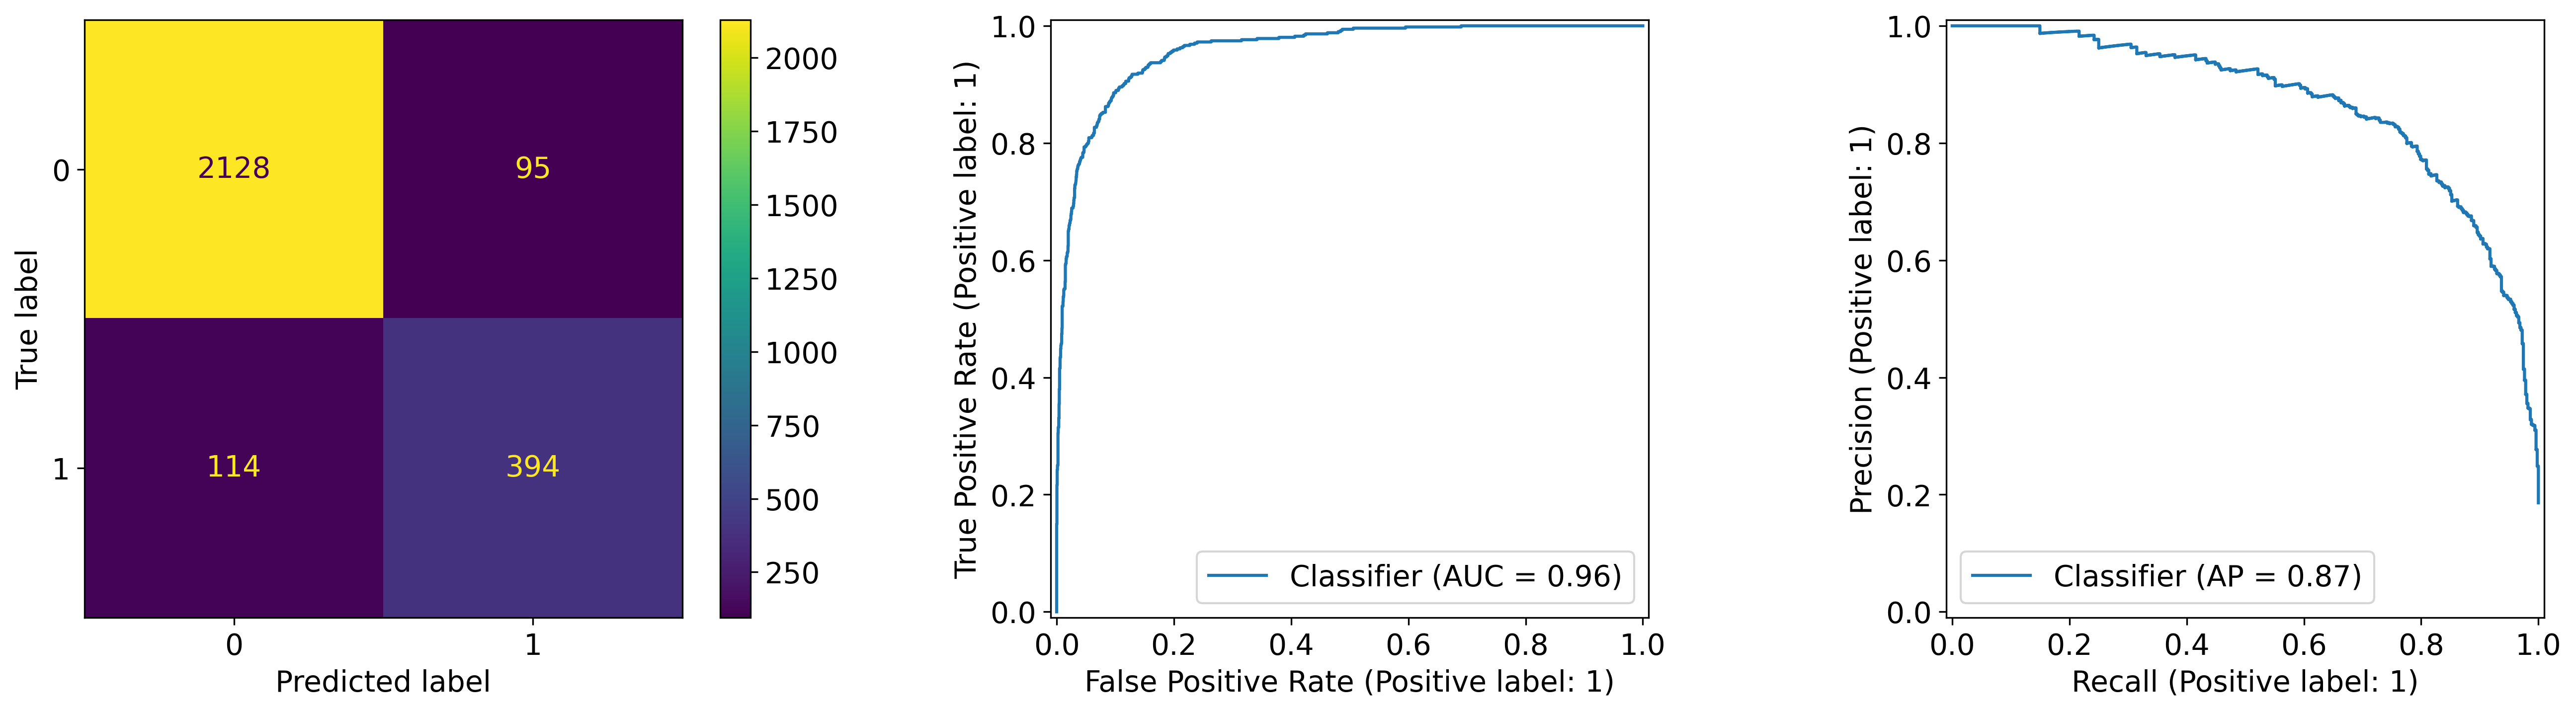

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MAE: 0.1138
RMSE: 0.2394
R²: 0.6215


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
from google.colab import files
import io

# ---- File Upload ----
pd_uploaded = files.upload()
sd_uploaded = files.upload()

project_file_name = list(pd_uploaded.keys())[0]
soil_file_name = list(sd_uploaded.keys())[0]

project_df = pd.read_csv(io.BytesIO(pd_uploaded[project_file_name]))
soil_df = pd.read_csv(io.BytesIO(sd_uploaded[soil_file_name]))

print("Project Data:")
print(project_df.head())
print("\nSoil Data:")
print(soil_df.head())

# ---- Merge Data ----
soil_agg = soil_df.groupby("WISE_ID").mean().reset_index()
merged_df = pd.merge(project_df, soil_agg, on="WISE_ID")

# ---- Setup Features and Labels ----
X_success = merged_df.drop(columns=[
    "WISE_ID", "Success", "LoadBearingCapacity (kPa)",
    "AlternativeUse", "ModificationRecommendation"
])
y_success = merged_df["Success"].astype(int)

categorical_cols = ["ConstructionType"]
numerical_cols = X_success.columns.difference(categorical_cols)

# ---- Preprocessor ----
success_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# ---- SVM Model ----
success_model = Pipeline([
    ("preprocessor", success_preprocessor),
    ("classifier", SVC(kernel="rbf", probability=True, C=100, random_state=42))
])

# ---- Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_success, y_success, stratify=y_success, random_state=42
)

# ---- Train Model ----
success_model.fit(X_train, y_train)

# ---- Predictions ----
y_pred = success_model.predict(X_test)
y_prob = success_model.predict_proba(X_test)[:, 1]  # Probability for class 1

# Cross-validation
cv_scores = cross_val_score(success_model, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# ---- Evaluation ----
print(classification_report(y_test, y_pred))
# Plots
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
#ax[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
#ax[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
#ax[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

# Save plots for download
fig.savefig("model_evaluation_SVM.png", dpi=300, bbox_inches="tight")
files.download("model_evaluation_SVM.png")
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# ---- Regression-like metrics using probabilities ----
mae = mean_absolute_error(y_test, y_prob)
rmse = np.sqrt(mean_squared_error(y_test, y_prob))
r2 = r2_score(y_test, y_prob)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

ANN

Saving project_dataset.csv to project_dataset (14).csv


Saving soil_profile_dataset.csv to soil_profile_dataset (14).csv
Project Data:
  WISE_ID      ConstructionType  LoadBearingCapacity (kPa)  \
0   AR041  Residential Building                         50   
1   AR041    High-rise Building                        150   
2   AR041              Low-rise                        100   
3   AR041      Roads & Highways                         70   
4   AR041               Bridges                        120   

         AlternativeUse          ModificationRecommendation  Success  
0                   NaN                                 NaN     True  
1  Residential Building  Reduce liquid limit via compaction    False  
2  Residential Building  Reduce liquid limit via compaction    False  
3                   NaN                                 NaN     True  
4  Residential Building  Reduce liquid limit via compaction    False  

Soil Data:
  WISE_ID  TOPDEP  BOTDEP  SAND  SILT  CLAY  GRAVEL  BULKDENS   OMC  MDD  \
0   AR041     0.0    26.0  47.0  3

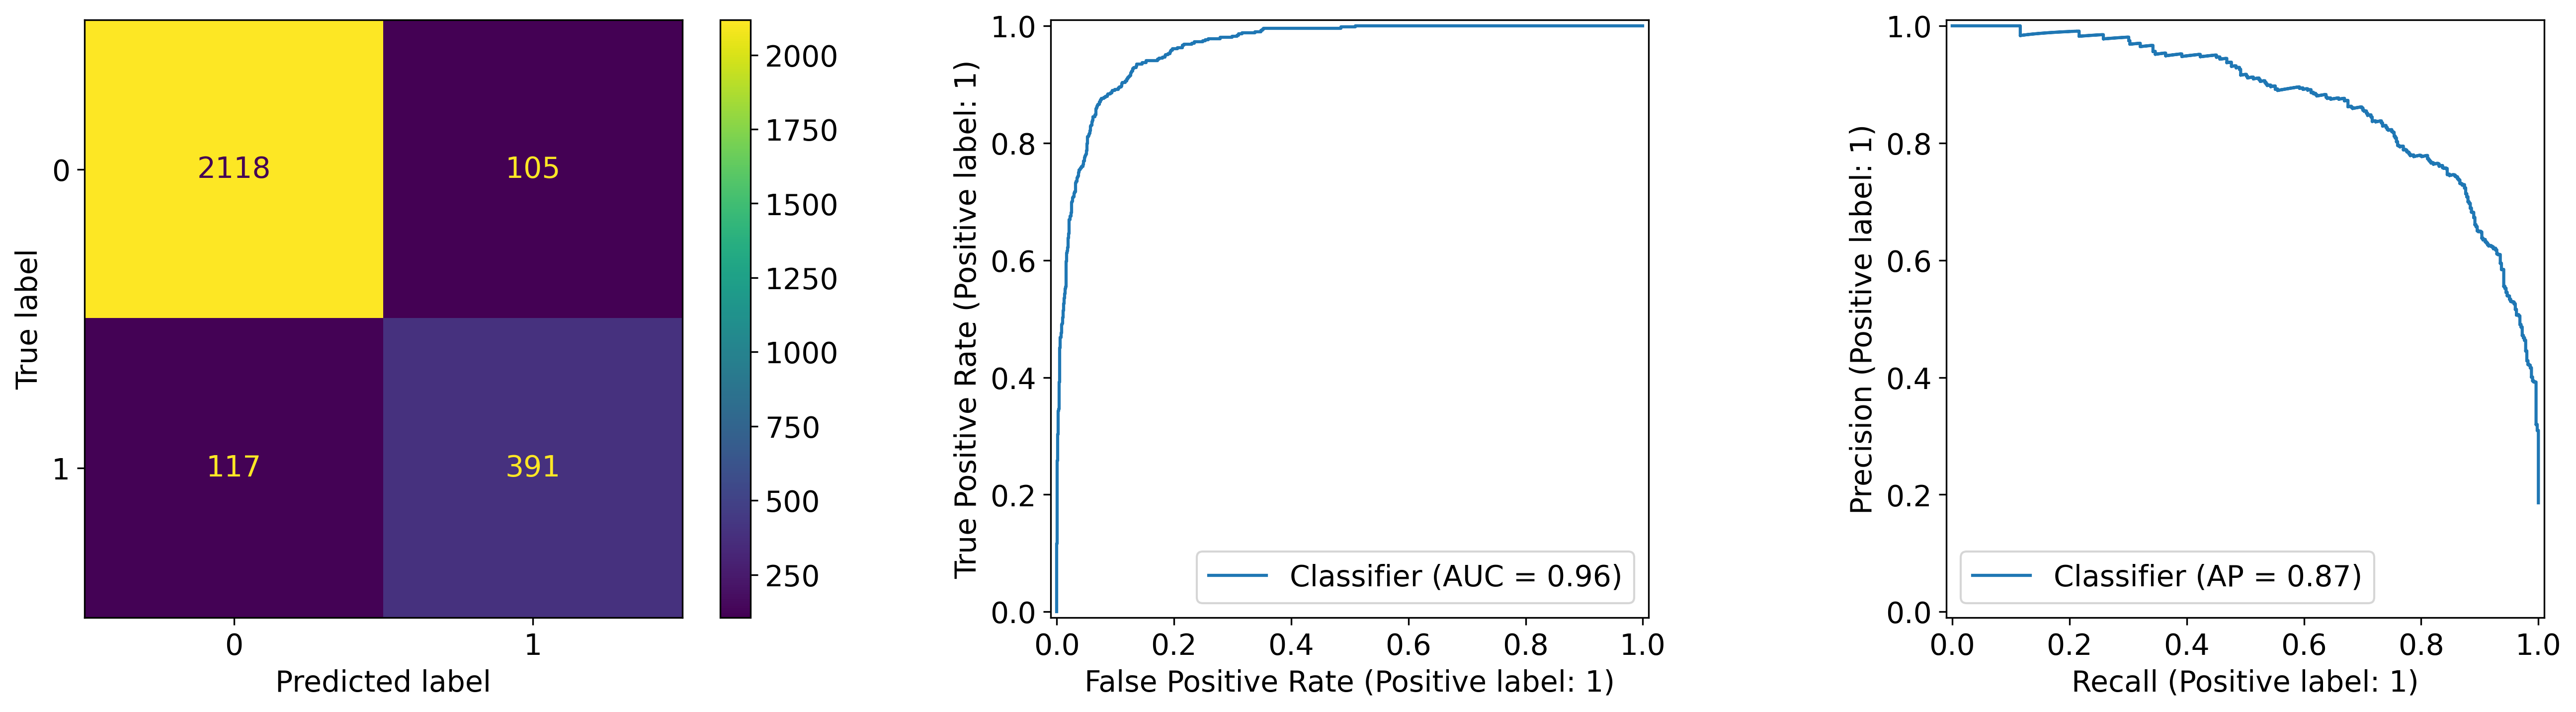

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
from google.colab import files
import io

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from scikeras.wrappers import KerasClassifier

# ---- File Upload ----
pd_uploaded = files.upload()
sd_uploaded = files.upload()

project_file_name = list(pd_uploaded.keys())[0]
soil_file_name = list(sd_uploaded.keys())[0]

project_df = pd.read_csv(io.BytesIO(pd_uploaded[project_file_name]))
soil_df = pd.read_csv(io.BytesIO(sd_uploaded[soil_file_name]))

print("Project Data:")
print(project_df.head())
print("\nSoil Data:")
print(soil_df.head())

# ---- Merge Data ----
soil_agg = soil_df.groupby("WISE_ID").mean().reset_index()
merged_df = pd.merge(project_df, soil_agg, on="WISE_ID")

# ---- Features & Labels ----
X_success = merged_df.drop(columns=[
    "WISE_ID", "Success", "LoadBearingCapacity (kPa)",
    "AlternativeUse", "ModificationRecommendation"
])
y_success = merged_df["Success"].astype(int)

categorical_cols = ["ConstructionType"]
numerical_cols = X_success.columns.difference(categorical_cols)

# ---- Preprocessor ----
success_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# ---- ANN Builder ----
def build_ann(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

# ---- Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_success, y_success, stratify=y_success, random_state=42
)

# Fit preprocessor first to know ANN input size
success_preprocessor.fit(X_train)
input_shape = success_preprocessor.transform(X_train).shape[1:]

# ---- ANN Pipeline ----
success_model = Pipeline([
    ("preprocessor", success_preprocessor),
    ("classifier", KerasClassifier(
        model=build_ann,
        model__input_shape=input_shape,
        epochs=50,
        batch_size=32,
        random_state=42,
        verbose=0
    ))
])

# ---- Train Model ----
success_model.fit(X_train, y_train)

# ---- Predictions ----
X_test_transformed = success_model.named_steps["preprocessor"].transform(X_test)
y_pred = success_model.named_steps["classifier"].predict(X_test_transformed)
y_prob = success_model.named_steps["classifier"].predict_proba(X_test_transformed)

# Handle probability shape
if isinstance(y_prob, (np.ndarray, list)) and y_prob.ndim > 1 and y_prob.shape[1] > 1:
    y_prob = y_prob[:, 1]

# ---- Evaluation ----
print(classification_report(y_test, y_pred))
# Plots
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
#ax[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
#ax[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
#ax[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


In [ ]:
# Save plots for download
fig.savefig("model_ANN.png", dpi=300, bbox_inches="tight")
files.download("model_ANN.png")

# ---- Regression-like metrics using probabilities ----
mae = mean_absolute_error(y_test, y_prob)
rmse = np.sqrt(mean_squared_error(y_test, y_prob))
r2 = r2_score(y_test, y_prob)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MAE: 0.0909
RMSE: 0.2423
R²: 0.6121


In [ ]:
### try or leave

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
from google.colab import files
import io

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from scikeras.wrappers import KerasClassifier

# ---- File Upload ----
pd_uploaded = files.upload()
sd_uploaded = files.upload()

project_file_name = list(pd_uploaded.keys())[0]
soil_file_name = list(sd_uploaded.keys())[0]

project_df = pd.read_csv(io.BytesIO(pd_uploaded[project_file_name]))
soil_df = pd.read_csv(io.BytesIO(sd_uploaded[soil_file_name]))

print("Project Data:")
print(project_df.head())
print("\nSoil Data:")
print(soil_df.head())

# ---- Merge Data ----
soil_agg = soil_df.groupby("WISE_ID").mean().reset_index()
merged_df = pd.merge(project_df, soil_agg, on="WISE_ID")

# ---- Features & Labels ----
X_success = merged_df.drop(columns=[
    "WISE_ID", "Success", "LoadBearingCapacity (kPa)",
    "AlternativeUse", "ModificationRecommendation"
])
y_success = merged_df["Success"].astype(int)

categorical_cols = ["ConstructionType"]
numerical_cols = X_success.columns.difference(categorical_cols)

# ---- Preprocessor ----
success_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# ---- ANN Builder ----
def build_ann(input_shape, n_hidden=2, n_neurons=64, dropout=0.2, lr=1e-3):
    model = Sequential()
    model.add(Input(shape=input_shape))
    for _ in range(n_hidden):
        model.add(Dense(n_neurons, activation="relu"))
        model.add(Dropout(dropout))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ---- Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_success, y_success, stratify=y_success, random_state=42
)

# Fit preprocessor first to know ANN input size
success_preprocessor.fit(X_train)
input_shape = success_preprocessor.transform(X_train).shape[1:]

# ---- ANN Pipeline ----
success_model = Pipeline([
    ("preprocessor", success_preprocessor),
    ("classifier", KerasClassifier(
        model=build_ann,
        model__input_shape=input_shape,
        epochs=50,
        batch_size=32,
        verbose=0,
        random_state=42
    ))
])

# ---- Training ----
success_model.fit(X_train, y_train)

# ---- Predictions ----
X_test_transformed = success_model.named_steps["preprocessor"].transform(X_test)
y_pred = success_model.named_steps["classifier"].predict(X_test_transformed)
y_prob = success_model.named_steps["classifier"].predict_proba(X_test_transformed)

if y_prob.ndim > 1 and y_prob.shape[1] > 1:
    y_prob = y_prob[:, 1]

# ---- Evaluation ----
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])

plt.tight_layout()
plt.show()
# Save plots for download
fig.savefig("model_ANN.png", dpi=300, bbox_inches="tight")
files.download("model_ANN.png")


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# ---- Regression-like metrics using probabilities ----
mae = mean_absolute_error(y_test, y_prob)
rmse = np.sqrt(mean_squared_error(y_test, y_prob))
r2 = r2_score(y_test, y_prob)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Final comparison

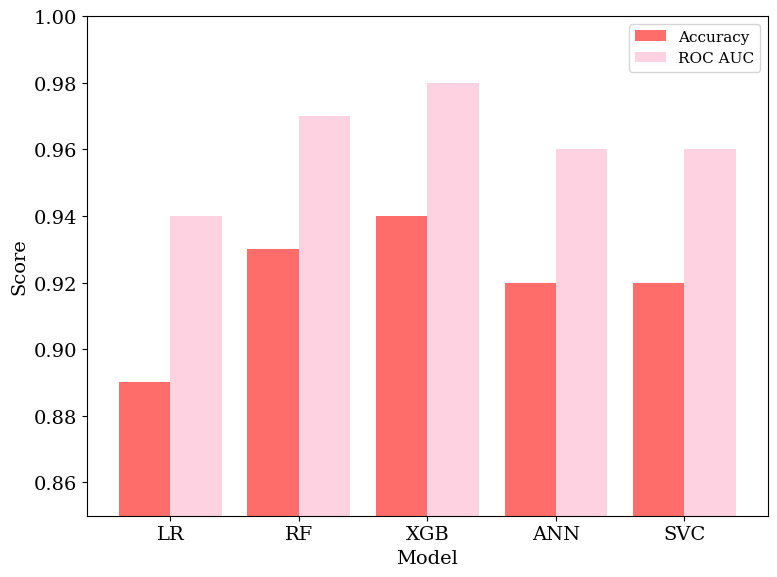

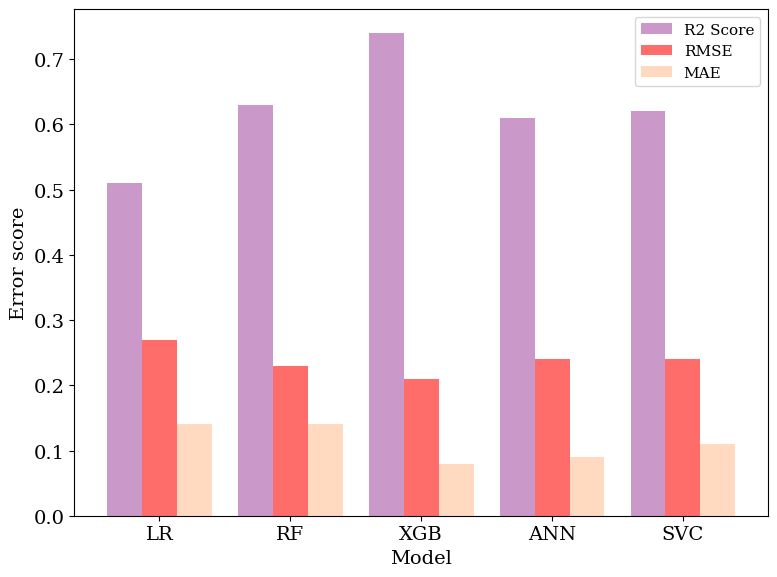

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data with abbreviations
data = {
"Model": ["LR", "RF", "XGB", "ANN", "SVC"],
 "Accuracy": [0.89, 0.93, 0.94, 0.92, 0.92],
 "ROC AUC": [0.94, 0.97, 0.98, 0.96, 0.96],
 "R2 Score": [0.51, 0.63, 0.74, 0.61, 0.62],
 "RMSE": [0.27, 0.23, 0.21, 0.24, 0.24],
 "MAE": [0.14, 0.14, 0.08, 0.09, 0.11],
}

df = pd.DataFrame(data)

# Plot style
plt.rcParams.update({"font.size": 14, "font.family": "serif"})

# Pastel color palettes
classification_colors = ["#FF6D6A", "#ffd2e1"]       # pastel yellow, pastel pink
error_colors = ["#cb99c9", "#FF6D6A", "#FFDAC1"]     # pastel , pasviolettel red, pastel peach

# --- Classification metrics plot ---
fig, ax = plt.subplots(figsize=(8, 6))
df.plot(
    x="Model",
    y=["Accuracy", "ROC AUC"],
    kind="bar",
    ax=ax,
    width=0.8,
    color=classification_colors
)

ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.legend(loc="upper right", fontsize=11, frameon=True)
ax.set_ylim(0.85, 1.0)   # <-- Y-axis range set here
plt.xticks(rotation=0)
#plt.yticks(0.65,0.1)

plt.tight_layout()
plt.savefig("classification_metrics.png", dpi=300)
plt.show()

# --- Error metrics plot ---
fig, ax = plt.subplots(figsize=(8, 6))
df.plot(
    x="Model",
    y=["R2 Score", "RMSE", "MAE"],
    kind="bar",
    ax=ax,
    width=0.8,
    color=error_colors
)

ax.set_ylabel("Error score")
ax.set_xlabel("Model")
ax.legend(loc="upper right", fontsize=11, frameon=True)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("error_metrics.png", dpi=300)
plt.show()


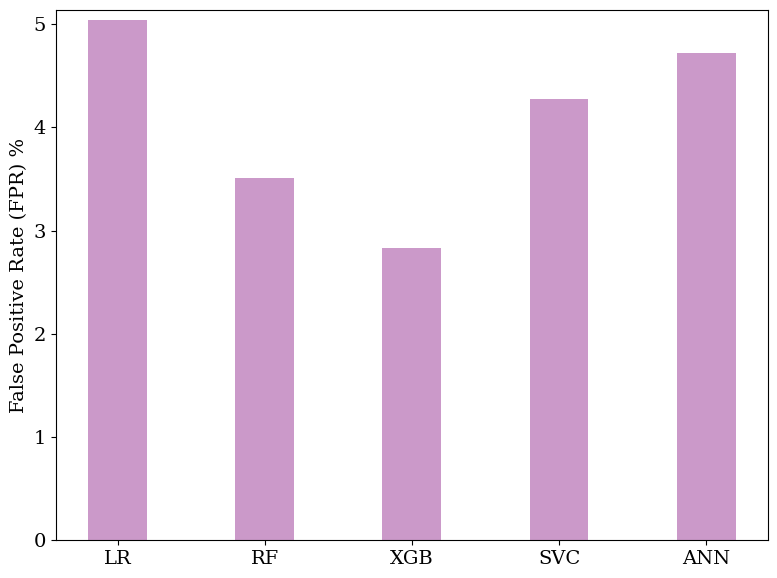

In [ ]:
import matplotlib.pyplot as plt

# FPR values for each classifier (from earlier calculations)
fpr_values = {
    "LR": 112*100 / (112 + 2111),
    "RF": 78 *100/ (78 + 2145),
    "XGB": 63 *100/ (63 + 2160),
    "SVC": 95*100 / (95 + 2128),
    "ANN": 105*100 / (105 + 2118)
}

# Extract keys and values
models = list(fpr_values.keys())
fpr_scores = [v for v in fpr_values.values()]

# Create bar plot with pastel colors
plt.rcParams.update({"font.size": 14})
plt.figure(figsize=(8, 6))

bars = plt.bar(models, fpr_scores, color="#cb99c9",width=0.4)

# Add labels and title
plt.ylabel("False Positive Rate (FPR) %")
#plt.title("FPR Comparison Across Classifiers")
plt.ylim(0, max(fpr_scores) + 0.1)


#plt.xticks(ha="right")


plt.tight_layout()
plt.savefig("FPR_metrics.png", dpi=300)
plt.show()
